In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn.objects as so
import os
import sys
import scipy
import pandas
import math
import torch

notebook_dir = os.getcwd()
project_root_dir = os.path.dirname(notebook_dir) # This should resolve to /path/to/project_root/
if project_root_dir not in sys.path:
    sys.path.insert(0, project_root_dir)

import h5py
import numpy as np
from dataset import load_dataset
from config import DatasetConfig

In [4]:
dataset = load_dataset(DatasetConfig(db_file="../dataset/micro_xs_1000-01.h5.sampled", label="micro_xs"))

In [9]:
dataset.trainX.shape[0]
filter_mask = np.ones(dataset.trainX.shape[0], dtype=bool)
#filter_mask = (dataset.trainX[:, 0] > -1) & (0 < dataset.trainX[:, 1]) & (dataset.trainX[:, 1] < 1) & (dataset.trainY[:, 0] < 20)
X = dataset.trainX[filter_mask]
dataset.trainX.shape, X.shape

(torch.Size([84158, 2]), torch.Size([84158, 2]))

In [22]:
# Representative Data
datasetX = dataset.trainX.numpy()[filter_mask]
datasetY = dataset.trainY.numpy()[filter_mask]
datasetX = dataset.validateX
datasetY = dataset.validateY
# Position
x0 = datasetX[:,0]
x1 = datasetX[:,1]

y0 = datasetY[:,0]
y1 = datasetY[:,1]
y2 = datasetY[:,2]
y3 = datasetY[:,3]

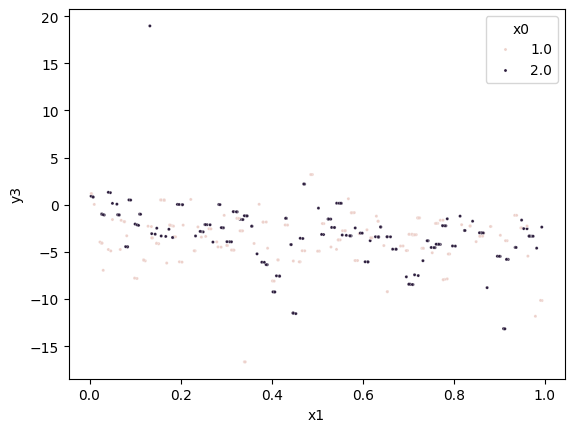

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Create a data frame from torch arrays dataset.trainX and dataset.trainY
df = pd.DataFrame(
    {
        "x0": x0,
        "x1": x1,
        "y0": y0,
        "y1": y1,
        "y2": y2,
        "y3": y3,
    }
)
# Plot y0, y1, y2, y3 as different colored scatter plots with x1 in the x-axis
# Take points where x0 = 1
# use small markers 
sns.scatterplot(df[(df["x0"] >= 1) & (df["x0"] <= 2)], x="x1", y="y3",  s=5, hue="x0")
#plt.scatter(x1, y0)
plt.show()



In [25]:
# Baseline error with smoothl1 loss
import torch.nn as nn
import torch
dY = dataset.trainY
l = dataset.trainY.shape[0]
mean_output = dataset.trainY.mean(axis=0)

print("Training loss for baseline model")
print("SmoothL1", nn.functional.smooth_l1_loss(torch.tensor(dY), torch.tensor(mean_output), reduction='sum').item() / l)
print("L1", nn.functional.l1_loss(torch.tensor(dY), torch.tensor(mean_output), reduction='sum').item() / l)
print("L2", nn.functional.mse_loss(torch.tensor(dY), torch.tensor(mean_output), reduction='sum').item() / l)


dY = dataset.validateY
l = dY.shape[0]
print("Validation loss for baseline model")
print("SmoothL1", nn.functional.smooth_l1_loss(torch.tensor(dY), torch.tensor(mean_output), reduction='sum').item() / l)
print("L1", nn.functional.l1_loss(torch.tensor(dY), torch.tensor(mean_output), reduction='sum').item() / l)
print("L2", nn.functional.mse_loss(torch.tensor(dY), torch.tensor(mean_output), reduction='sum').item() / l)



Training loss for baseline model
SmoothL1 7.01329629513297
L1 8.797029142724702
L2 59.0741203760583
Validation loss for baseline model
SmoothL1 7.052343153696653
L1 8.836435867062649
L2 57.21360970772248


/tmp/ipykernel_4169056/801669311.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  print("SmoothL1", nn.functional.smooth_l1_loss(torch.tensor(dY), torch.tensor(mean_output), reduction='sum').item() / l)
/tmp/ipykernel_4169056/801669311.py:9: UserWarning: Using a target size (torch.Size([4])) that is different to the input size (torch.Size([84158, 4])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  print("SmoothL1", nn.functional.smooth_l1_loss(torch.tensor(dY), torch.tensor(mean_output), reduction='sum').item() / l)
/tmp/ipykernel_4169056/801669311.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  print("L1", nn.functional.

In [24]:
data = [
    {"name": "x0", "value":x0},
    {"name": "x1", "value":x1},
    {"name": "y0", "value":y0, "log":True},
    {"name":  "y1", "value":y1, "log":True},
    {"name": "y2", "value":y2, "log":True},
    {"name":  "y3", "value":y3, "log":True}
]


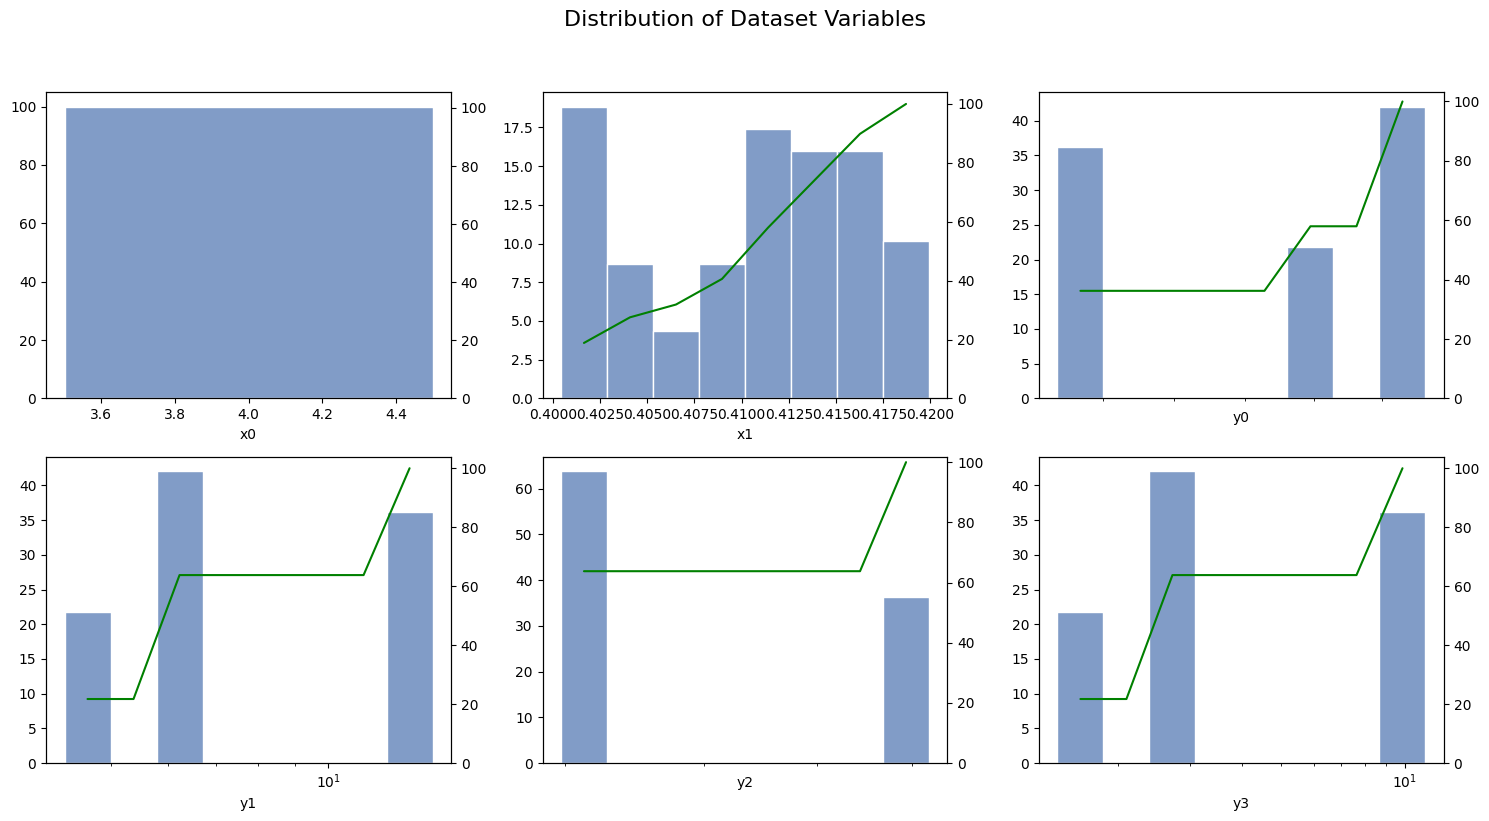

In [93]:
num_variables = len(data)
num_cols = 3
num_rows = math.ceil(num_variables / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows), squeeze=False)
axes_flat = axes.flatten() # Flatten the 2D array of axes for easy iteration

# --- 5. Iterate Through Variables and Plot on Subplots ---
def plot(i, var_name, values, bins="auto", log=False):
    ax = axes_flat[i]

    plot_instance1 = (
        so.Plot(x=np.abs(values) if log else values)
        .on(ax) # Attach this plot to ax1
        .add(so.Bars(), so.Hist(bins=bins, stat='percent'))
    )

    ax2 = ax.twinx()
    plot_instance2 = (
        so.Plot(x=np.abs(values) if log else values)
        .on(ax2) # Attach this plot to ax1
        .add(so.Line(color='green'), so.Hist(bins=bins, stat='percent', cumulative=True))
        .limit(y=(0, None))
    )

    if log:
        plot_instance1 = plot_instance1.scale(x='log')
        plot_instance2 = plot_instance2.scale(x='log')

    plot_instance1.plot()
    plot_instance2.plot()

    ax2.yaxis.tick_right()
    ax.set_xlabel(var_name)

for (i, d) in enumerate(data):
    plot(i, d["name"], d["value"], log=d.get("log"), bins=d.get("bins") or "auto")
for j in range(num_variables, len(axes_flat)):
    fig.delaxes(axes_flat[j])

fig.tight_layout()
fig.suptitle("Distribution of Dataset Variables", fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to make space for suptitle
plt.savefig("distribution.svg")

In [94]:
print(f"Variable                  =     Mean (+/-  Std. Dev) [    Minimum,       Maximum]")
print("-" * 81)
for d in data:
    v = d["value"]
    print(f"{d["name"]:25} = {np.mean(v):+.5f} (+/- {np.std(v):9.6f}) [{np.min(v):12.6f}, {np.max(v):12.6f}]")

print(f"Total Datapoints: {data[0]['value'].size}")

Variable                  =     Mean (+/-  Std. Dev) [    Minimum,       Maximum]
---------------------------------------------------------------------------------
x0                        = +4.00000 (+/-  0.000000) [    4.000000,     4.000000]
x1                        = +0.41046 (+/-  0.005988) [    0.400428,     0.419927]
y0                        = +2.86425 (+/-  0.111872) [    2.718971,     2.982679]
y1                        = +8.44766 (+/-  4.185411) [    4.313483,    13.955935]
y2                        = +5.25763 (+/-  1.459585) [    3.972533,     7.193629]
y3                        = -5.58341 (+/-  4.287506) [  -11.236964,    -1.422571]
Total Datapoints: 69


In [28]:
y0

array([2.72428918, 2.8889873 , 2.72196865, 2.89061904, 2.71962142,
       2.97007918, 2.89067125, 2.71984196, 2.89070821, 2.89091182,
       2.9822731 , 2.962152  , 2.72030067, 2.97152877, 2.88928485,
       2.71920943, 2.72314501, 2.89059258, 2.71924543, 2.97580194,
       2.72315097, 2.9720974 , 2.7267065 , 2.97231531, 2.97344851,
       2.89016342, 2.9634726 , 2.88981819, 2.97967172, 2.98100996,
       2.71897125, 2.98250794, 2.89086318, 2.72476888, 2.8896656 ,
       2.72611833, 2.97478724, 2.96206808, 2.97490454, 2.72241163,
       2.98202491, 2.97220922, 2.98104739, 2.96220469, 2.97143841,
       2.980932  , 2.96239948, 2.72018766, 2.96332407, 2.7212286 ,
       2.97690105, 2.89059258, 2.7193923 , 2.72047687, 2.72640419,
       2.72593141, 2.72056031, 2.98267913, 2.8905592 , 2.9672029 ,
       2.72370934, 2.98057032, 2.7232945 , 2.71971798, 2.89010382,
       2.88947272, 2.71906924, 2.97641778, 2.97322536])